# Demo of a block encoding for 1D Laplacian with periodic boundary conditions

In [10]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit import Gate, ControlledGate

In [11]:
n = 3

In [ ]:
# Build S+ and S- gates
# These need to be reimplemented to match the little endian convention of Qiskit -> Done in shift_operators.py
class SPlusGate(Gate):
    def __init__(self):
        super().__init__("S+", n, [])

    def _define(self):
        qc = QuantumCircuit(n)
        qc.ccx(0, 1, 2)
        qc.cx(0, 1)
        qc.x(0)
        
        self.definition = qc


class SMinusGate(Gate):
    def __init__(self):
        super().__init__("S-", n, [])

    def _define(self):
        qc = QuantumCircuit(n)
        qc.x(0)
        qc.cx(0, 1)
        qc.ccx(0, 1, 2)

        self.definition = qc


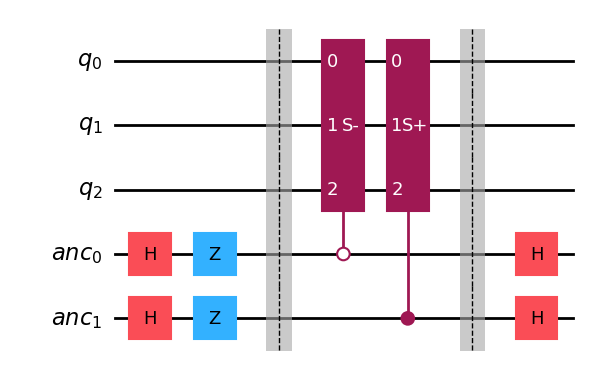

In [34]:
# Build circuit
main = QuantumRegister(n, "q")
ancilla = QuantumRegister(2, "anc")
qc = QuantumCircuit(main, ancilla)

qc.h(ancilla)
qc.z(ancilla)

qc.barrier()

c0sminus = SMinusGate().control(1, ctrl_state=0)
c1splus = SPlusGate().control(1)

qc.append(c0sminus, [ancilla[0]] + main[:])
qc.append(c1splus, [ancilla[1]] + main[:])

qc.barrier()

qc.h(ancilla)
qc.draw(output="mpl")